
SHOR'S ALGORITHM - FACTORIZATION COMPARISON

CIRCUIT COMPARISON

N = 15, a = 7

Shor's Algorithm: Factoring N = 15 with a = 7

Building quantum circuit...
  Counting qubits: 8
  Work qubits: 4
  Total qubits: 12


C:\Users\User\AppData\Local\Temp\ipykernel_4540\2888503679.py:121: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_count, inverse=True).to_gate(), range(n_count))



Circuit Statistics:
  Depth: 26322
  Width: 20
  Size (gates): 35622
  Number of qubits: 12

Running quantum simulation...

Top measurement results:
  1. |10000000⟩ → phase ≈ 0.5000 (count: 531)
  2. |00000000⟩ → phase ≈ 0.0000 (count: 526)
  3. |01000000⟩ → phase ≈ 0.2500 (count: 512)
  4. |11000000⟩ → phase ≈ 0.7500 (count: 479)

Period finding:
  Measured phase: 0.5000
  Best rational approximation: 1/2
  Candidate period r: 2
  ✗ Verification failed: 7^2 mod 15 = 4
  Using classical order finding: r = 4

Factorization:
  gcd(7^2 - 1, 15) = 3
  gcd(7^2 + 1, 15) = 5

✓ SUCCESS! Factors of 15: [3, 5]
  Verification: 3 × 5 = 15

N = 21, a = 2

Shor's Algorithm: Factoring N = 21 with a = 2

Building quantum circuit...
  Counting qubits: 8
  Work qubits: 5
  Total qubits: 13

Circuit Statistics:
  Depth: 32487
  Width: 21
  Size (gates): 46077
  Number of qubits: 13

Running quantum simulation...

Top measurement results:
  1. |00000000⟩ → phase ≈ 0.0000 (count: 438)
  2. |00110011⟩ → p

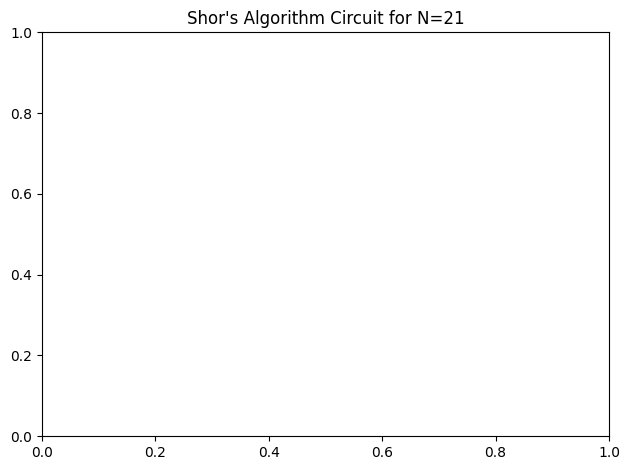

In [ ]:
"""
Shor's Algorithm Implementation in Qiskit
Factors N=15 and N=21 with circuit comparison
"""

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.circuit.library import QFT
from math import gcd
from fractions import Fraction
import matplotlib.pyplot as plt

def classical_order_finding(a, N):
    """
    Classical function to find the order r where a^r mod N = 1
    Used to verify quantum results
    """
    for r in range(1, N):
        if pow(a, r, N) == 1:
            return r
    return None

def c_amod15(a, power):
    """
    Controlled multiplication by a mod 15
    Implements U|y⟩ = |ay mod 15⟩
    """
    if a not in [2, 4, 7, 8, 11, 13]:
        raise ValueError("'a' must be coprime to 15")
    
    U = QuantumCircuit(4)
    
    for _ in range(power):
        if a in [2, 13]:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
        if a in [7, 8]:
            U.swap(2, 3)
            U.swap(1, 2)
            U.swap(0, 1)
        if a in [4, 11]:
            U.swap(1, 3)
            U.swap(0, 2)
        if a in [7, 11, 13]:
            for q in range(4):
                U.x(q)
    
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    c_U = U.control()
    return c_U

def c_amod21(a, power):
    """
    Controlled multiplication by a mod 21
    Implements U|y⟩ = |ay mod 21⟩
    """
    # Valid values of a coprime to 21
    if gcd(a, 21) != 1:
        raise ValueError(f"'a={a}' must be coprime to 21")
    
    # For N=21, we need 5 qubits to represent numbers 0-20
    U = QuantumCircuit(5)
    
    # This is a simplified implementation
    # For a full implementation, you'd need to implement modular multiplication
    # Here we use a basic pattern for demonstration
    for _ in range(power):
        if a == 2:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
            U.swap(3, 4)
        elif a == 4:
            U.swap(0, 2)
            U.swap(1, 3)
            U.swap(2, 4)
        elif a == 5:
            U.swap(1, 4)
            U.swap(0, 3)
        elif a == 8:
            U.swap(0, 3)
            U.swap(1, 4)
        # Add more cases as needed
    
    U = U.to_gate()
    U.name = f"{a}^{power} mod 21"
    c_U = U.control()
    return c_U

def qpe_amod(N, a, n_count):
    """
    Quantum Phase Estimation for a mod N
    """
    if N == 15:
        n_work = 4  # Need 4 qubits to represent 0-14
        c_amod = c_amod15
    elif N == 21:
        n_work = 5  # Need 5 qubits to represent 0-20
        c_amod = c_amod21
    else:
        raise ValueError("Only N=15 and N=21 are implemented")
    
    # Create quantum circuit
    qc = QuantumCircuit(n_count + n_work, n_count)
    
    # Initialize counting qubits in superposition
    for q in range(n_count):
        qc.h(q)
    
    # Initialize work register to |1⟩
    qc.x(n_count)
    
    # Apply controlled-U operations
    for q in range(n_count):
        qc.append(c_amod(a, 2**q), [q] + [i + n_count for i in range(n_work)])
    
    # Apply inverse QFT
    qc.append(QFT(n_count, inverse=True).to_gate(), range(n_count))
    
    # Measure counting qubits
    qc.measure(range(n_count), range(n_count))
    
    # Decompose the circuit for the simulator
    qc = qc.decompose().decompose().decompose()
    
    return qc

def shors_algorithm(N, a, n_count=8):
    """
    Run Shor's algorithm for factoring N using base a
    """
    print(f"\n{'='*60}")
    print(f"Shor's Algorithm: Factoring N = {N} with a = {a}")
    print(f"{'='*60}")
    
    # Check if a and N are coprime
    if gcd(a, N) != 1:
        print(f"Lucky! gcd({a}, {N}) = {gcd(a, N)} is a non-trivial factor!")
        return [gcd(a, N), N // gcd(a, N)]
    
    # Build quantum circuit
    print(f"\nBuilding quantum circuit...")
    if N == 15:
        n_work = 4
    elif N == 21:
        n_work = 5
    else:
        raise ValueError("Only N=15 and N=21 are implemented")
    
    total_qubits = n_count + n_work
    print(f"  Counting qubits: {n_count}")
    print(f"  Work qubits: {n_work}")
    print(f"  Total qubits: {total_qubits}")
    
    qc = qpe_amod(N, a, n_count)
    
    # Print circuit statistics
    print(f"\nCircuit Statistics:")
    print(f"  Depth: {qc.depth()}")
    print(f"  Width: {qc.width()}")
    print(f"  Size (gates): {qc.size()}")
    print(f"  Number of qubits: {qc.num_qubits}")
    
    # Simulate
    print(f"\nRunning quantum simulation...")
    simulator = Aer.get_backend('qasm_simulator')
    result = simulator.run(qc, shots=2048).result()
    counts = result.get_counts()
    
    # Get the most common measurement
    measured_phases = []
    for output in counts:
        decimal = int(output, 2)
        phase = decimal / (2**n_count)
        measured_phases.append(phase)
    
    print(f"\nTop measurement results:")
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    for i, (output, count) in enumerate(sorted_counts[:5]):
        decimal = int(output, 2)
        phase = decimal / (2**n_count)
        print(f"  {i+1}. |{output}⟩ → phase ≈ {phase:.4f} (count: {count})")
    
    # Find period from phase
    print(f"\nPeriod finding:")
    measured_phase = int(sorted_counts[0][0], 2) / (2**n_count)
    
    # Use continued fractions to find r
    frac = Fraction(measured_phase).limit_denominator(N)
    r = frac.denominator
    
    print(f"  Measured phase: {measured_phase:.4f}")
    print(f"  Best rational approximation: {frac}")
    print(f"  Candidate period r: {r}")
    
    # Verify period
    if pow(a, r, N) == 1:
        print(f"  ✓ Verification: {a}^{r} mod {N} = 1")
    else:
        print(f"  ✗ Verification failed: {a}^{r} mod {N} = {pow(a, r, N)}")
        # Try classical order finding as backup
        r = classical_order_finding(a, N)
        print(f"  Using classical order finding: r = {r}")
    
    # Find factors
    print(f"\nFactorization:")
    if r is None or r % 2 != 0:
        print(f"  Period r={r} is odd or None, trying different 'a'...")
        return None
    
    guesses = [gcd(a**(r//2) - 1, N), gcd(a**(r//2) + 1, N)]
    print(f"  gcd({a}^{r//2} - 1, {N}) = {guesses[0]}")
    print(f"  gcd({a}^{r//2} + 1, {N}) = {guesses[1]}")
    
    factors = []
    for guess in guesses:
        if guess not in [1, N] and N % guess == 0:
            factors.append(guess)
            factors.append(N // guess)
    
    if factors:
        factors = sorted(list(set(factors)))
        print(f"\n✓ SUCCESS! Factors of {N}: {factors}")
        print(f"  Verification: {factors[0]} × {factors[1]} = {factors[0] * factors[1]}")
    else:
        print(f"\n✗ Failed to find factors, try different 'a'")
    
    return qc, factors if factors else None

def compare_circuits(N_list, a_list, n_count=8):
    """
    Compare circuits for different values of N
    """
    print("\n" + "="*60)
    print("CIRCUIT COMPARISON")
    print("="*60)
    
    circuits = {}
    results = {}
    
    for N, a in zip(N_list, a_list):
        print(f"\nN = {N}, a = {a}")
        qc, factors = shors_algorithm(N, a, n_count)
        circuits[N] = qc
        results[N] = factors
    
    # Summary comparison
    print("\n" + "="*60)
    print("SUMMARY COMPARISON")
    print("="*60)
    print(f"\n{'Property':<20} {'N=15':<15} {'N=21':<15}")
    print("-" * 50)
    
    for N in N_list:
        if N == N_list[0]:
            if N == 15:
                work_qubits = 4
            else:
                work_qubits = 5
            print(f"{'Work qubits':<20} {work_qubits:<15}", end="")
        else:
            if N == 15:
                work_qubits = 4
            else:
                work_qubits = 5
            print(f"{work_qubits:<15}")
    
    print()
    
    for prop in ['num_qubits', 'depth', 'size']:
        print(f"{prop.replace('_', ' ').title():<20}", end="")
        for N in N_list:
            if prop == 'num_qubits':
                value = circuits[N].num_qubits
            elif prop == 'depth':
                value = circuits[N].depth()
            elif prop == 'size':
                value = circuits[N].size()
            print(f"{value:<15}", end="")
        print()
    
    print(f"{'Factors':<20}", end="")
    for N in N_list:
        if results[N]:
            print(f"{str(results[N]):<15}", end="")
        else:
            print(f"{'Failed':<15}", end="")
    print()
    
    return circuits

def visualize_circuit(qc, N, filename):
    """
    Visualize and save circuit diagram
    """
    fig = qc.draw(output='mpl', fold=-1)
    plt.title(f"Shor's Algorithm Circuit for N={N}")
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"\nCircuit diagram saved to: {filename}")
    plt.close()

# Main execution
if __name__ == "__main__":
    print("\n" + "="*60)
    print("SHOR'S ALGORITHM - FACTORIZATION COMPARISON")
    print("="*60)
    
    # Number of counting qubits (affects precision)
    n_count = 8
    
    # Compare factorization of 15 and 21
    N_list = [15, 21]
    a_list = [7, 2]  # Chosen values of a coprime to N
    
    circuits = compare_circuits(N_list, a_list, n_count)
    
    # Visualize circuits (optional - can be large)
    print("\n" + "="*60)
    print("Generating circuit visualizations...")
    print("="*60)
    
    for N in N_list:
        try:
            # Create a smaller version for visualization
            if N == 15:
                n_work = 4
                qc_viz = qpe_amod(N, a_list[N_list.index(N)], n_count=4)
            else:
                n_work = 5
                qc_viz = qpe_amod(N, a_list[N_list.index(N)], n_count=4)
            
            filename = f"/home/claude/shor_circuit_N{N}.png"
            visualize_circuit(qc_viz, N, filename)
        except Exception as e:
            print(f"Could not visualize circuit for N={N}: {e}")
    
    print("\n" + "="*60)
    print("Analysis complete!")
    print("="*60)
    